# **Lab Complementario - Caso 1**
---
*   JUAN PABLO CARO LARA
*   JOSEPH ABRAHAM PINZON ALVARADO
*   EMMANUEL VILLADA SUAREZ

# **1. Exploración del dataset**

In [3]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/SEMINARIO CIENCIA DE DATOS/Laboratorios/loans.csv")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,client_id,age,income,loan_amount,credit_score,loan_purpose,late_payments,loan_status
0,1006,38,2700.0,800.0,705.0,business,0,approved
1,1007,50,1600.0,500.0,610.0,health,2,rejected
2,1008,27,3100.0,1200.0,720.0,education,0,approved
3,1009,44,1900.0,650.0,640.0,personal,1,approved
4,1010,36,2400.0,700.0,675.0,education,0,approved


# **2. Estadísticas descriptivas**

In [4]:
df.describe()

,client_id,age,income,loan_amount,credit_score,late_payments
count,100.000000,100.000000,98.000000,99.000000,99.000000,100.000000
mean,1055.500000,39.710000,2283.163265,705.757576,661.010101,1.230000
std,29.011492,8.274697,567.184395,216.738773,49.088528,1.246044
min,1006.000000,27.000000,1300.000000,300.000000,560.000000,0.000000
25%,1030.750000,33.000000,1750.000000,550.000000,620.000000,0.000000
50%,1055.500000,39.000000,2350.000000,700.000000,670.000000,1.000000
75%,1080.250000,47.000000,2737.500000,850.000000,700.000000,2.000000
max,1105.000000,55.000000,3300.000000,1200.000000,735.000000,4.000000


# **3. Identificar variables**

In [5]:
df.dtypes

,0
client_id,int64
age,int64
income,float64
loan_amount,float64
credit_score,float64
loan_purpose,object
late_payments,int64
loan_status,object


# **4. Análisis de mora**

In [ ]:
df.groupby("loan_status")["late_payments"].mean()

,late_payments
loan_status,
approved,0.421875
rejected,2.666667


# **5. Distribución del ingreso de clientes**

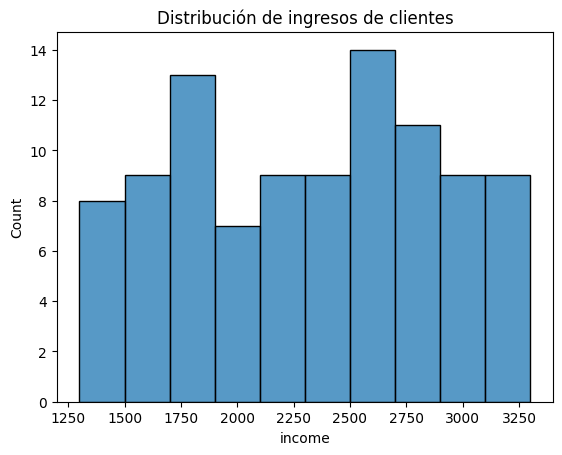

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["income"], bins=10)
plt.title("Distribución de ingresos de clientes")
plt.show()

# **6. Relación ingreso vs monto del préstamo**


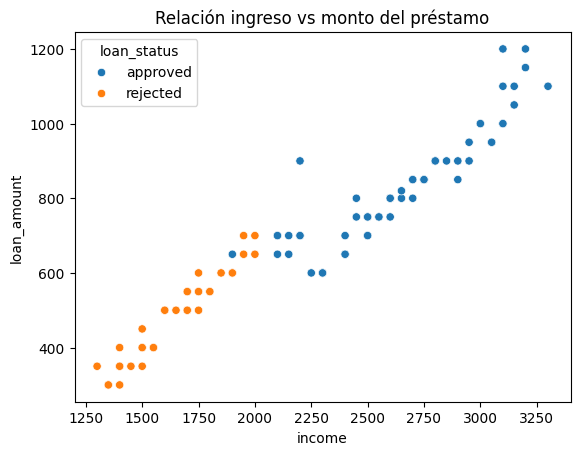

In [ ]:
sns.scatterplot(x="income", y="loan_amount", hue="loan_status", data=df)
plt.title("Relación ingreso vs monto del préstamo")
plt.show()

# **7. Distribución de credit score**

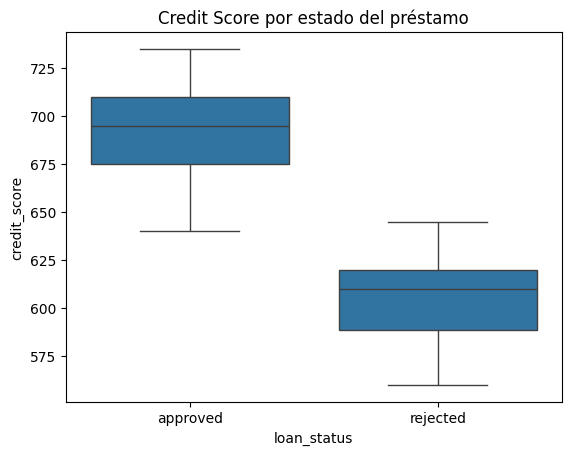

In [ ]:
sns.boxplot(x="loan_status", y="credit_score", data=df)
plt.title("Credit Score por estado del préstamo")
plt.show()

# **8. Correlación entre variables numéricas**

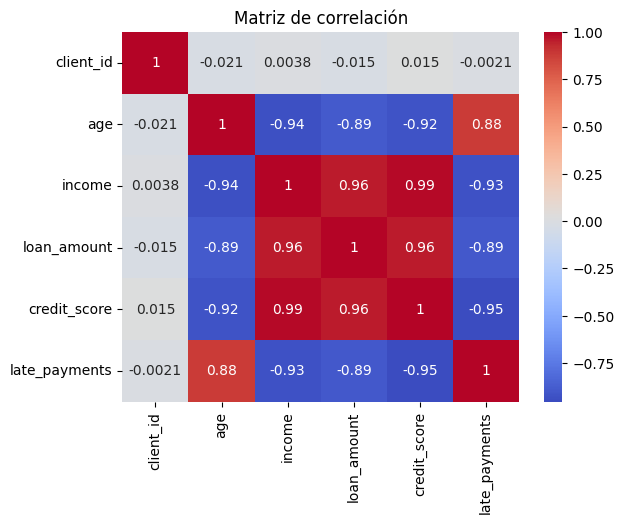

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

# **9. Ratio deuda ingreso**


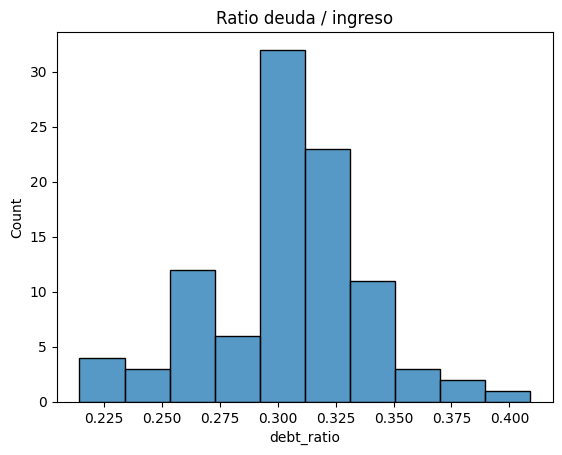

In [ ]:
df["debt_ratio"] = df["loan_amount"] / df["income"]

sns.histplot(df["debt_ratio"], bins=10)
plt.title("Ratio deuda / ingreso")
plt.show()

## **Pregunta 1: ¿Qué variables influyen más en la aprobación del crédito?**
## **Respuesta:**

Las variables más influyentes son:

* **Credit Score:** Factor principal. Aprobados tienen score > 650, rechazados < 630.

* **Relación Deuda/Ingreso (debt_ratio):** Préstamos altos vs ingresos bajos = rechazo.

* **Pagos atrasados:** Rechazados tienen más late_payments (2-3 vs 0-1).

* **Ingreso:** Influye indirectamente a través del debt_ratio.

---

## **Pregunta 2: ¿Qué problemas de calidad de datos observan?**
## **Respuesta:**

Problemas identificados:

* **Valores nulos:** income (filas 1031,1094), loan_amount (1035), credit_score (1048), loan_purpose (1034)

* **Outliers:** Casos extremos de ingresos muy bajos con montos altos

* **Escala pequeña:** Solo 100 registros, muestra insuficiente

* **Patrón en nulos:** Posible sesgo si no son aleatorios

---

## **Pregunta 3: ¿Qué arquitectura usarían si el volumen creciera 100x?**
## **Respuesta:**

Arquitectura **Lakehouse** por capas:

* **Data Lake:** Almacenar datos crudos (S3/Blob Storage) en formato Parquet

* **Procesamiento:** Spark para ETL distribuido

* **Lakehouse:** Capa analítica con Databricks/Synapse

* **Consumo:** Modelos ML y dashboards

---

## **Pregunta 4: ¿Cómo aplicarían CRISP-DM a este caso?**
## **Respuesta:**

* **Business Understanding:** Objetivo: reducir mora y mejorar evaluación crediticia

* **Data Understanding:** EDA realizado (distribuciones, correlaciones, debt_ratio)

* **Data Preparation:** Limpiar nulos, crear variables (debt_ratio), escalar

* **Modeling:** Probar modelos (Regresión Logística, Random Forest)

* **Evaluation:** Métricas: precisión, recall (enfoque en minimizar falsos aprobados)

* **Deployment:** API para evaluación en tiempo real + monitoreo continuo

## **Conclusiones del análisis exploratorio**

* Los clientes aprobados tienen credit score promedio > 650, mientras que rechazados < 630

* Existe una relación inversa entre pagos atrasados y aprobación: a más late_payments, más rechazos

* El ratio deuda/ingreso es un predictor clave: valores > 0.4 suelen ser rechazados

* Se identificaron valores nulos en 4 registros que requieren tratamiento

* El dataset actual (100 registros) es útil para análisis exploratorio pero insuficiente para modelado robusto

## **Recomendaciones para CrediNova**

* Implementar credit score mínimo de 650 como filtro inicial

* Evaluar automáticamente el ratio deuda/ingreso, rechazando solicitudes > 0.4

* Integrar más fuentes de datos (transacciones bancarias, historial completo) para enriquecer el análisis

* Escalar a arquitectura Lakehouse cuando el volumen lo requiera